# 0.0 IMPORTS

In [4]:
import pandas as pd
import inflection
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 0.1 Helper Functions

## 0.2 Loading data

In [5]:
# Dataset import
df_sales_raw = pd.read_csv("../Dataset/train.csv", low_memory=False)
df_store_raw = pd.read_csv("../Dataset/store.csv", low_memory=False)

# Merging datasets
df_raw = pd.merge(df_sales_raw, df_store_raw, how="left", on="Store")


## 1.0 Descrição dos Dados

## 1.1 Rename Columns

In [6]:
df1 = df_raw.copy()

In [7]:
df1.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [8]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval']

In [9]:
# Renaming columns
snakecase = lambda x: inflection.underscore(x)
cals_new = list(map(snakecase, cols_old))

df1.columns = cals_new
df1.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval'],
      dtype='str')

## 1.2 Data Dimension

In [10]:
df1.shape

(1017209, 18)

In [11]:
print("Number of rows: ", (df1.shape[0]))
print("Number of columns: ", (df1.shape[1]))

Number of rows:  1017209
Number of columns:  18


## 1.3 Data Types

In [12]:
df1.dtypes

store                             int64
day_of_week                       int64
date                                str
sales                             int64
customers                         int64
open                              int64
promo                             int64
state_holiday                       str
school_holiday                    int64
store_type                          str
assortment                          str
competition_distance            float64
competition_open_since_month    float64
competition_open_since_year     float64
promo2                            int64
promo2_since_week               float64
promo2_since_year               float64
promo_interval                      str
dtype: object

In [13]:
df1['date'] = pd.to_datetime(df1['date'])
df1['promo_interval'] = df1['promo_interval'].astype(object)
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
dtype: object

In [14]:
df1.head(5)


,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 1.4 Check NA

In [15]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## 1.5 Fillout NA

In [16]:
df1['competition_distance'].max()

np.float64(75860.0)

In [17]:
# competition_distance
df1['competition_distance']= df1['competition_distance'].apply (lambda x: 200000.0 if math.isnan(x) else x)
           
# competition_open_since_month
df1['competition_open_since_month'] = df1.apply ( lambda x: x["date"].month if math.isnan(x['competition_open_since_month'])else x['competition_open_since_month'], axis=1)

# competition_open_since_year
df1['competition_open_since_year'] = df1.apply ( lambda x: x["date"].year if math.isnan(x['competition_open_since_year'])else x['competition_open_since_year'], axis=1)

# promo2_since_week
df1['promo2_since_week'] = df1.apply ( lambda x: x["date"].week if math.isnan(x['promo2_since_week'])else x['promo2_since_week'], axis=1)         

# promo2_since_year
df1['promo2_since_year'] = df1.apply ( lambda x: x["date"].year if math.isnan(x['promo2_since_year'])else x['promo2_since_year'], axis=1)

# promo_interval
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dez',}

df1['promo_interval']= df1['promo_interval'].fillna ('0')
df1['month_map'] = df1['date'].dt.month.map(month_map)
df1['promo_interval'].unique()
df1['is_promo']= df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval']=='0' else 1 if x['month_map']in x['promo_interval'].split(',') else 0, axis=1)

In [18]:
df1.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
dtype: int64

## 1.6 Change Types

In [31]:
df1['competition_open_since_month']=df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year']=df1['competition_open_since_year'].astype(int)
df1['promo2_since_week']=df1['promo2_since_week'].astype(int)
df1['promo2_since_year']=df1['promo2_since_year'].astype(int)
df1['promo_interval']=df1['promo_interval'].astype(str)

df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                             str
month_map                                  str
is_promo                                 int64
dtype: object

## 1.7 Descripted Statistical

In [33]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])
cat_attributes.head()

,state_holiday,store_type,assortment,promo_interval,month_map
0,0,c,a,0,Jul
1,0,a,a,"Jan,Apr,Jul,Oct",Jul
2,0,a,a,"Jan,Apr,Jul,Oct",Jul
3,0,c,c,0,Jul
4,0,a,a,0,Jul


In [34]:
cat_attributes.dtypes

state_holiday     str
store_type        str
assortment        str
promo_interval    str
month_map         str
dtype: object

In [43]:
cat_attributes.shape

(1017209, 5)

## 1.7.1 Numerical Attributes

In [35]:
# Central tendency - mean, median
ct1 =pd.DataFrame(num_attributes.apply(np.mean)).transpose()
ct2 =pd.DataFrame(num_attributes.apply(np.median)).transpose()

# Dispersion - std (standard deviation/desvio padrão), min, max, range, quartiles
d1 = pd.DataFrame(num_attributes.apply(np.std)).transpose()
d2 = pd.DataFrame(num_attributes.apply(min)).transpose()
d3 = pd.DataFrame(num_attributes.apply(max)).transpose()
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).transpose()

# Measures of shape - skewness, kurtosis (assimetria = 0 proximo da normal, curtose = 1 proximo da normal) 
# Todos os pontos estão concentrados no centro, caudas mais leves, distribuição mais achatada do que a normal, curtose < 3, caudas mais pesadas, distribuição mais pontuda do que a normal, curtose > 3
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).transpose()
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).transpose()

# Concatenating tables
m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skewness', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skewness,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


<Axes: xlabel='sales', ylabel='Count'>

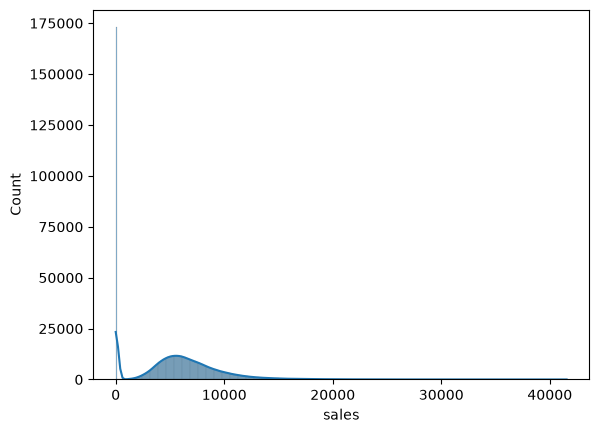

In [27]:
sns.histplot(df1['sales'], kde=True)

<Axes: xlabel='competition_distance', ylabel='Count'>

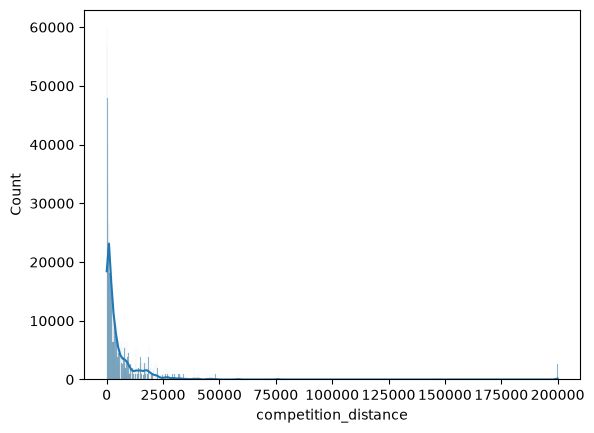

In [26]:
sns.histplot(df1['competition_distance'], kde=True)

## 1.7.2 Categorical Attributes

In [47]:
cat_attributes.apply(lambda x: x.nunique())

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

<Axes: xlabel='assortment', ylabel='sales'>

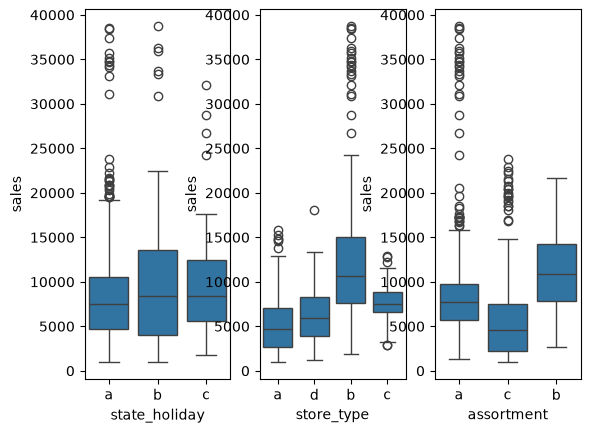

In [53]:
aux1 = df1[(df1['sales']>0) & (df1['state_holiday']!='0')]
# col, lin, posição do gráfico
plt.subplot(1,3,1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1,3,2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1,3,3)
sns.boxplot(x='assortment', y='sales', data=aux1)